# Loan Prediction Analysis

## Проєкт: Система передбачення схвалення займу

Цей notebook містить повний аналіз даних, підготовку моделі машинного навчання та візуалізації для системи передбачення схвалення займу.


## 1. EDA - Exploratory Data Analysis


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Налаштування для візуалізації
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# Завантаження даних
df = pd.read_csv("loan_data.csv")
print("Розмір датасету:", df.shape)
df.head()


Розмір датасету: (381, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [ ]:
# Загальна інформація про дані
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [ ]:
# Статистичний опис даних
df.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,381.000000,381.000000,381.000000,370.000000,351.000000
mean,3579.845144,1277.275381,104.986877,340.864865,0.837607
std,1419.813818,2340.818114,28.358464,68.549257,0.369338
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2600.000000,0.000000,90.000000,360.000000,1.000000
50%,3333.000000,983.000000,110.000000,360.000000,1.000000
75%,4288.000000,2016.000000,127.000000,360.000000,1.000000
max,9703.000000,33837.000000,150.000000,480.000000,1.000000


In [ ]:
# Перевірка пропусків
missing_values = df.isnull().sum()
print("Пропущені значення:")
print(missing_values[missing_values > 0])
print("\nВідсоток пропусків:")
print((missing_values[missing_values > 0] / len(df) * 100).round(2))


Пропущені значення:
Gender               5
Dependents           8
Self_Employed       21
Loan_Amount_Term    11
Credit_History      30
dtype: int64

Відсоток пропусків:
Gender              1.31
Dependents          2.10
Self_Employed       5.51
Loan_Amount_Term    2.89
Credit_History      7.87
dtype: float64


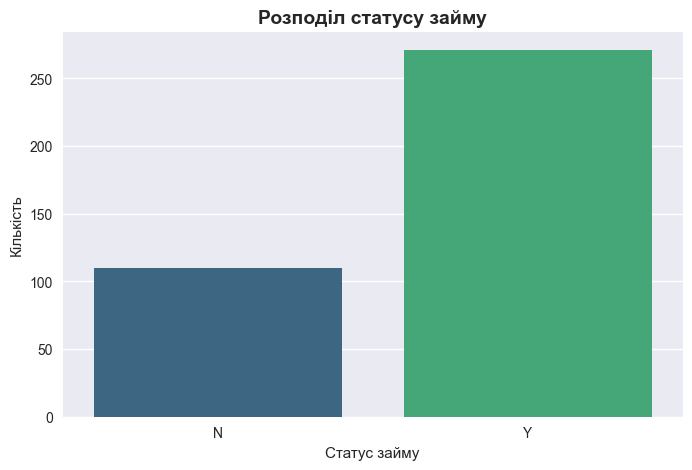

Розподіл:
Loan_Status
Y    271
N    110
Name: count, dtype: int64

Відсотки:
Loan_Status
Y    71.128609
N    28.871391
Name: proportion, dtype: float64


In [ ]:
# Розподіл цільової змінної
plt.figure(figsize=(8, 5))
sns.countplot(x='Loan_Status', data=df, palette='viridis')
plt.title('Розподіл статусу займу', fontsize=14, fontweight='bold')
plt.xlabel('Статус займу')
plt.ylabel('Кількість')
plt.show()

print("Розподіл:")
print(df['Loan_Status'].value_counts())
print("\nВідсотки:")
print(df['Loan_Status'].value_counts(normalize=True) * 100)


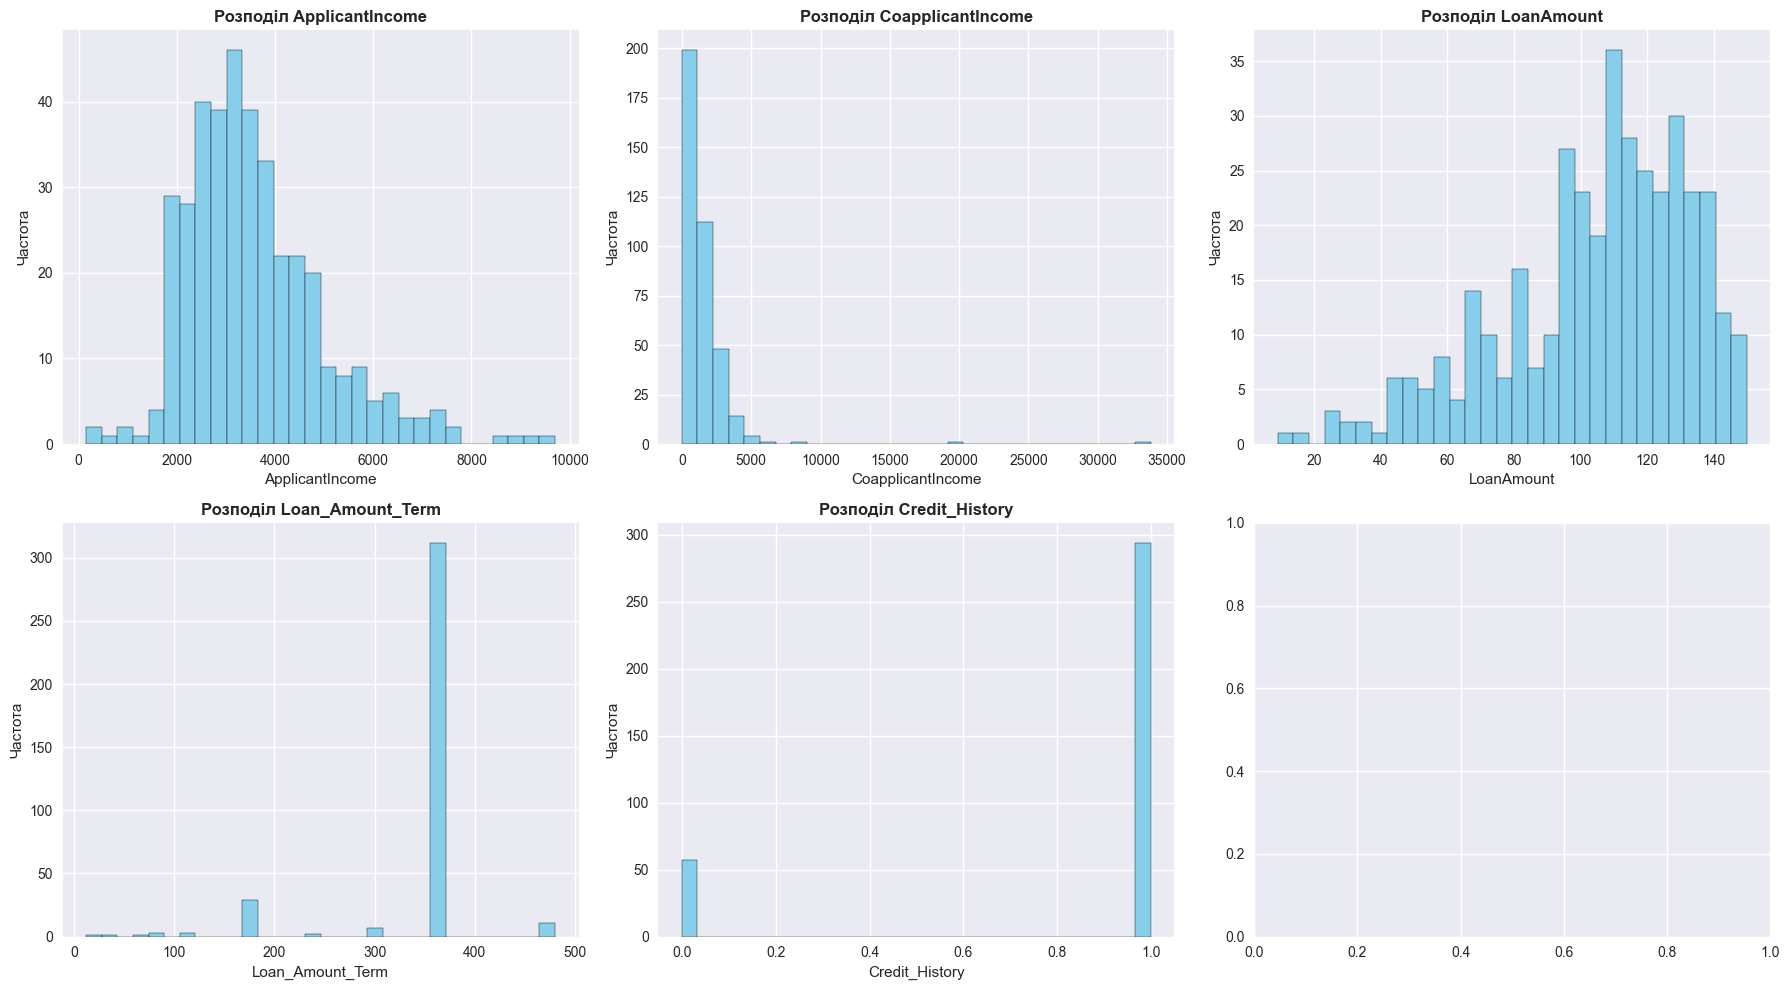

In [ ]:
# Розподіли числових змінних
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'Loan_ID']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(numeric_cols[:6]):
    df[col].hist(bins=30, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Розподіл {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Частота')

plt.tight_layout()
plt.show()


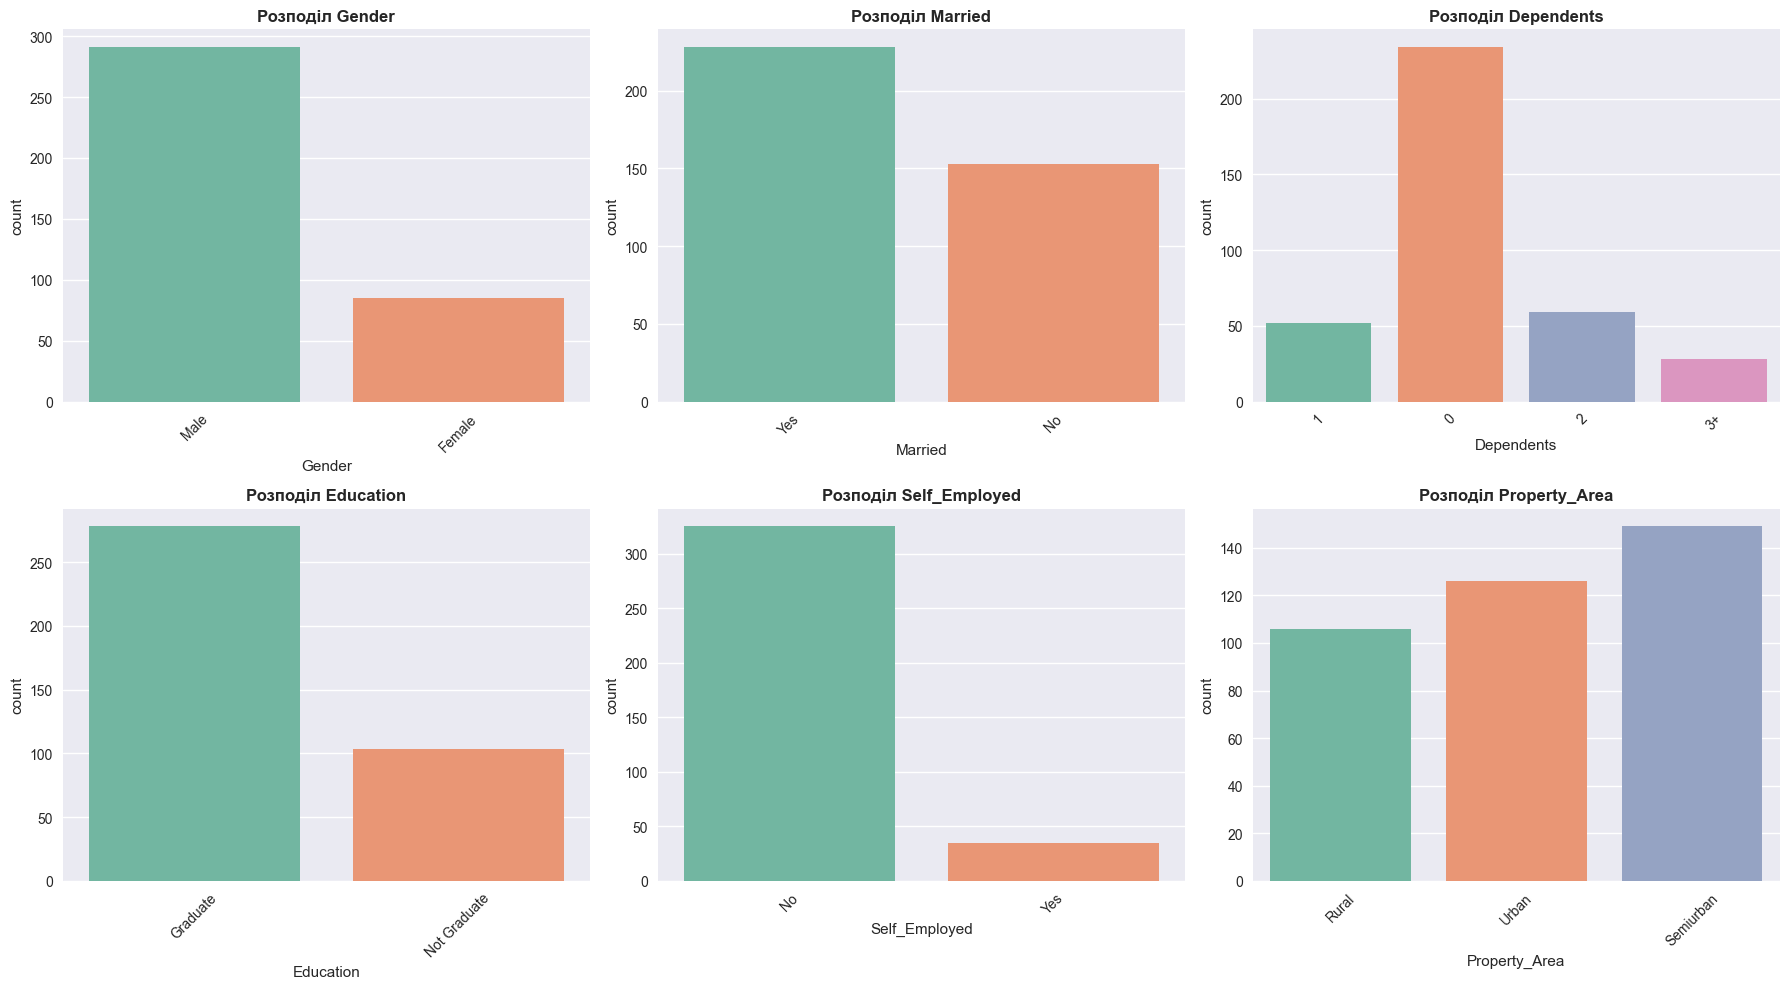

In [ ]:
# Розподіли категоріальних змінних
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
categorical_cols = [col for col in categorical_cols if col not in ['Loan_ID', 'Loan_Status']]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Розподіл {col}', fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


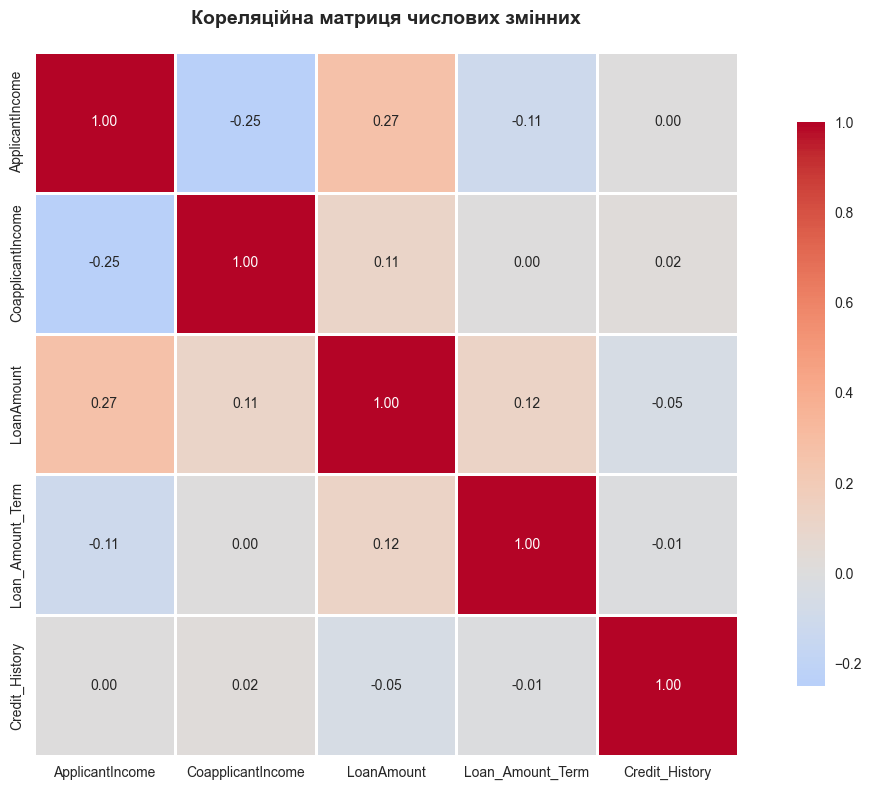

In [ ]:
# Кореляційна матриця
plt.figure(figsize=(12, 8))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Кореляційна матриця числових змінних', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


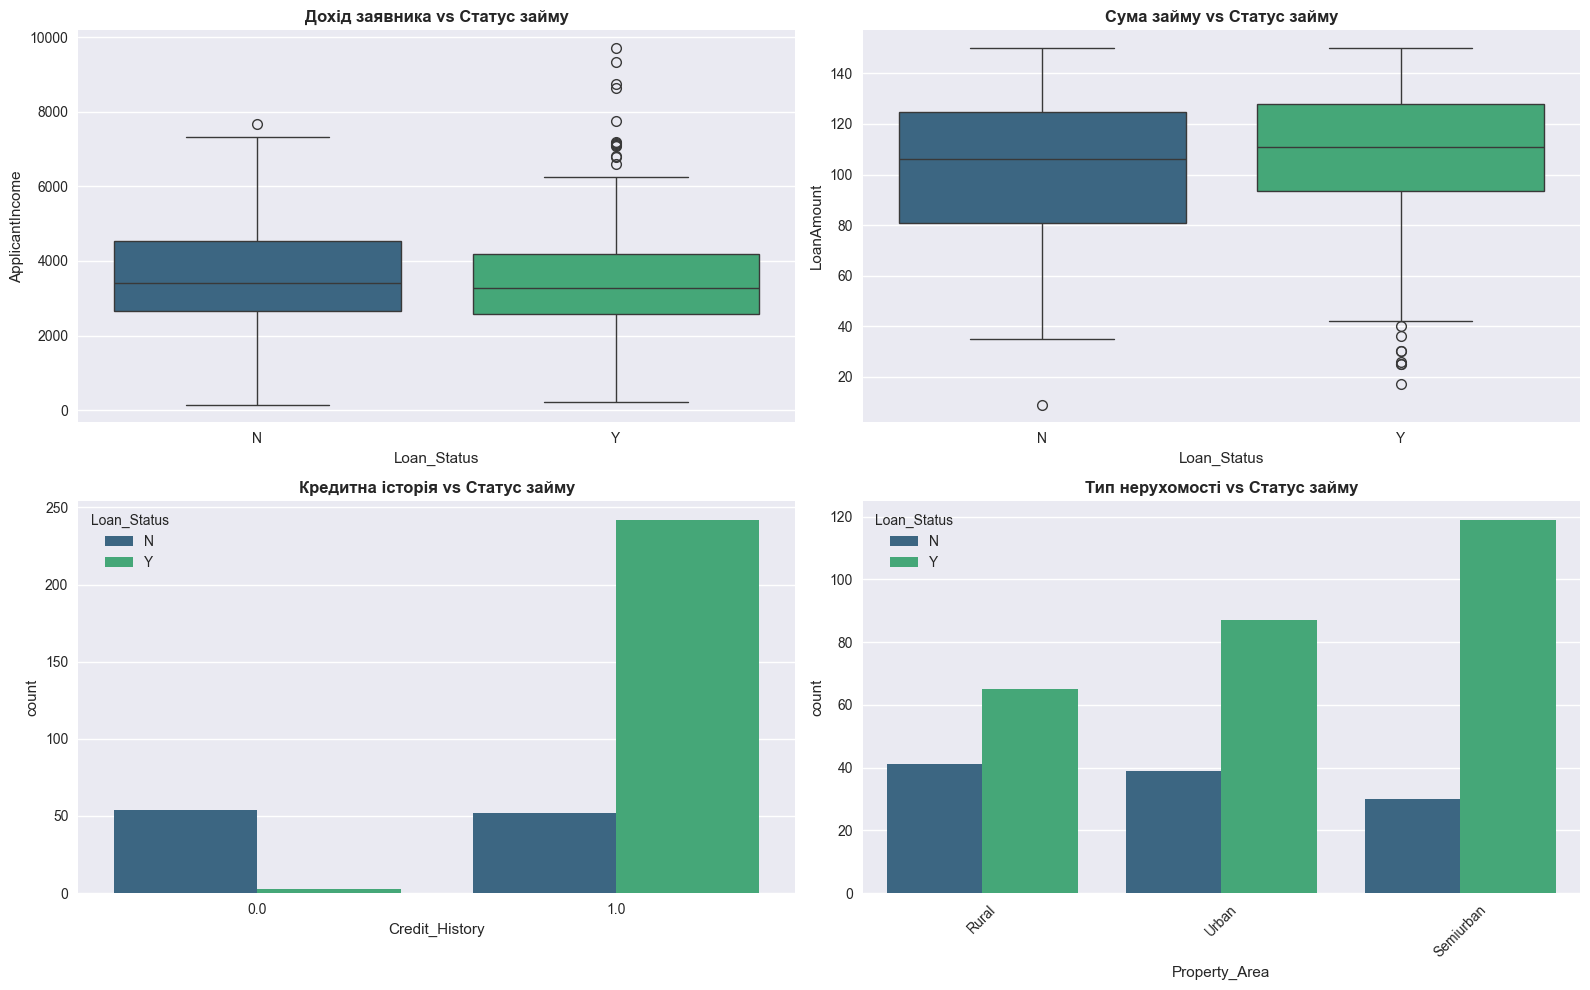

In [ ]:
# Зв'язок між змінними та цільовою змінною
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ApplicantIncome vs Loan_Status
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df, ax=axes[0, 0], palette='viridis')
axes[0, 0].set_title('Дохід заявника vs Статус займу', fontweight='bold')

# LoanAmount vs Loan_Status
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df, ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Сума займу vs Статус займу', fontweight='bold')

# Credit_History vs Loan_Status
sns.countplot(x='Credit_History', hue='Loan_Status', data=df, ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Кредитна історія vs Статус займу', fontweight='bold')

# Property_Area vs Loan_Status
sns.countplot(x='Property_Area', hue='Loan_Status', data=df, ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Тип нерухомості vs Статус займу', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## 2. Cleaning - Очищення даних


In [ ]:
# Створюємо копію датасету для обробки
df_clean = df.copy()

# Заповнення пропусків для категоріальних змінних
df_clean['Gender'].fillna(df_clean['Gender'].mode()[0], inplace=True)
df_clean['Married'].fillna(df_clean['Married'].mode()[0], inplace=True)
df_clean['Dependents'].fillna(df_clean['Dependents'].mode()[0], inplace=True)
df_clean['Self_Employed'].fillna(df_clean['Self_Employed'].mode()[0], inplace=True)

# Заповнення пропусків для числових змінних
df_clean['LoanAmount'].fillna(df_clean['LoanAmount'].median(), inplace=True)
df_clean['Loan_Amount_Term'].fillna(df_clean['Loan_Amount_Term'].median(), inplace=True)
df_clean['Credit_History'].fillna(df_clean['Credit_History'].mode()[0], inplace=True)
df_clean['CoapplicantIncome'].fillna(0, inplace=True)

# Перевірка після очищення
print("Пропущені значення після очищення:")
print(df_clean.isnull().sum().sum())


Пропущені значення після очищення:
0


In [ ]:
# Обробка Dependents (заміна '3+' на '3')
df_clean['Dependents'] = df_clean['Dependents'].replace('3+', '3')

# Перетворення типів даних
df_clean['Dependents'] = df_clean['Dependents'].astype(int)
df_clean['Credit_History'] = df_clean['Credit_History'].astype(int)

print("Типи даних після перетворення:")
print(df_clean.dtypes)


Типи даних після перетворення:
Loan_ID               object
Gender                object
Married               object
Dependents             int32
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History         int32
Property_Area         object
Loan_Status           object
dtype: object


## 3. Encoding - Кодування категоріальних змінних


In [ ]:
# Підготовка даних для моделі
# Видаляємо Loan_ID (не потрібен для моделі)
X = df_clean.drop(['Loan_ID', 'Loan_Status'], axis=1)
y = df_clean['Loan_Status']

# Визначаємо числові та категоріальні стовпці
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Числові стовпці:", num_cols)
print("Категоріальні стовпці:", cat_cols)
print("\nФорма X:", X.shape)
print("Форма y:", y.shape)


Числові стовпці: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
Категоріальні стовпці: ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']

Форма X: (381, 11)
Форма y: (381,)


## 4. Scaling - Масштабування (буде в Pipeline)


## 5. Modeling - Створення моделі з Pipeline


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Створення попередньої обробки даних
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ],
    remainder='passthrough'
)

# Створення повного pipeline
# n_jobs=1 бо на Windows з multiprocessing проблеми
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=42, n_jobs=1))
])

print("Pipeline створено успішно!")


Pipeline створено успішно!


In [ ]:
# Розділення на тренувальний та тестовий набори
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Тренувальний набір: {X_train.shape}")
print(f"Тестовий набір: {X_test.shape}")


Тренувальний набір: (304, 11)
Тестовий набір: (77, 11)


## 6. Cross-Validation + GridSearchCV


In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_score

# Параметри для GridSearchCV
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 5, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

# Створення GridSearchCV
# n_jobs=1 бо на Windows з multiprocessing проблеми
grid = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='accuracy',
    n_jobs=1,
    verbose=1
)

print("Початок навчання моделі з GridSearchCV...")
grid.fit(X_train, y_train)

print("\nНайкращі параметри:")
print(grid.best_params_)
print(f"\nНайкраща оцінка (accuracy): {grid.best_score_:.4f}")


Початок навчання моделі з GridSearchCV...
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Найкращі параметри:
{'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 50}

Найкраща оцінка (accuracy): 0.8420


In [ ]:
# Cross-validation на повному тренувальному наборі
cv_scores = cross_val_score(grid.best_estimator_, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validation scores:", cv_scores)
print(f"Середня точність: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")


Cross-validation scores: [0.8852459  0.81967213 0.83606557 0.85245902 0.81666667]
Середня точність: 0.8420 (+/- 0.0502)


## 7. Evaluation - Оцінка моделі


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Передбачення на тестовому наборі
y_pred = grid.best_estimator_.predict(X_test)

# Точність
accuracy = accuracy_score(y_test, y_pred)
print(f"Точність на тестовому наборі: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Точність на тестовому наборі: 0.8571

Classification Report:
              precision    recall  f1-score   support

           N       1.00      0.50      0.67        22
           Y       0.83      1.00      0.91        55

    accuracy                           0.86        77
   macro avg       0.92      0.75      0.79        77
weighted avg       0.88      0.86      0.84        77



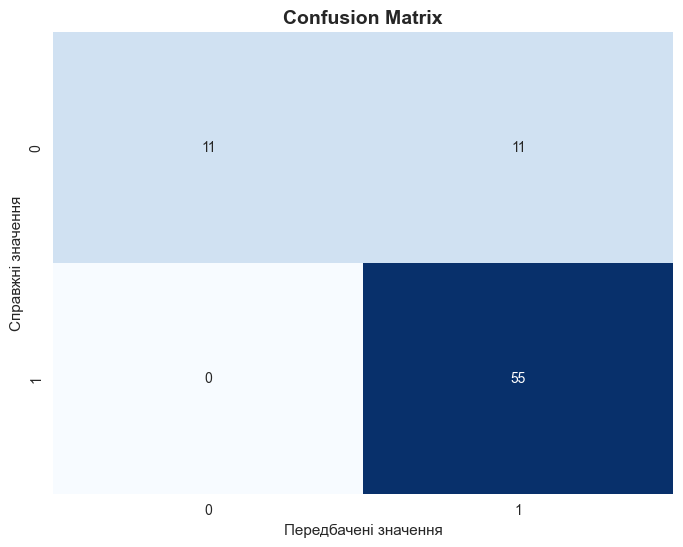

In [ ]:
# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Справжні значення')
plt.xlabel('Передбачені значення')
plt.show()


In [ ]:
# Важливість ознак
feature_importances = grid.best_estimator_.named_steps['model'].feature_importances_

# Отримуємо імена ознак після трансформації
preprocessor = grid.best_estimator_.named_steps['preprocessor']

# пробуємо отримати імена через get_feature_names_out (якщо є)
try:
    feature_names = preprocessor.get_feature_names_out()
except:
    # якщо немає цього методу, робимо вручну
    feature_names = []
    for name, transformer, columns in preprocessor.transformers_:
        if name == 'num':
            feature_names.extend(columns)
        elif name == 'cat':
            ohe = transformer
            for i, col in enumerate(columns):
                categories = ohe.categories_[i]
                # drop='first' означає що перша категорія пропущена
                for cat in categories[1:]:
                    feature_names.append(f"{col}_{cat}")
    
    # якщо все ще не співпадає, просто нумеруємо
    if len(feature_names) != len(feature_importances):
        feature_names = [f"Feature_{i}" for i in range(len(feature_importances))]

# Створюємо DataFrame з важливістю ознак
feature_importance_df = pd.DataFrame({
    'Feature': feature_names[:len(feature_importances)],
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Топ-15 найважливіших ознак:")
print(feature_importance_df.head(15))


Топ-15 найважливіших ознак:
                         Feature  Importance
11     remainder__Credit_History    0.475970
1         num__CoapplicantIncome    0.131247
0           num__ApplicantIncome    0.122547
2                num__LoanAmount    0.108848
3          num__Loan_Amount_Term    0.049709
5               cat__Married_Yes    0.024387
8   cat__Property_Area_Semiurban    0.024161
10         remainder__Dependents    0.023676
4               cat__Gender_Male    0.012084
6    cat__Education_Not Graduate    0.011893
9       cat__Property_Area_Urban    0.009688
7         cat__Self_Employed_Yes    0.005790


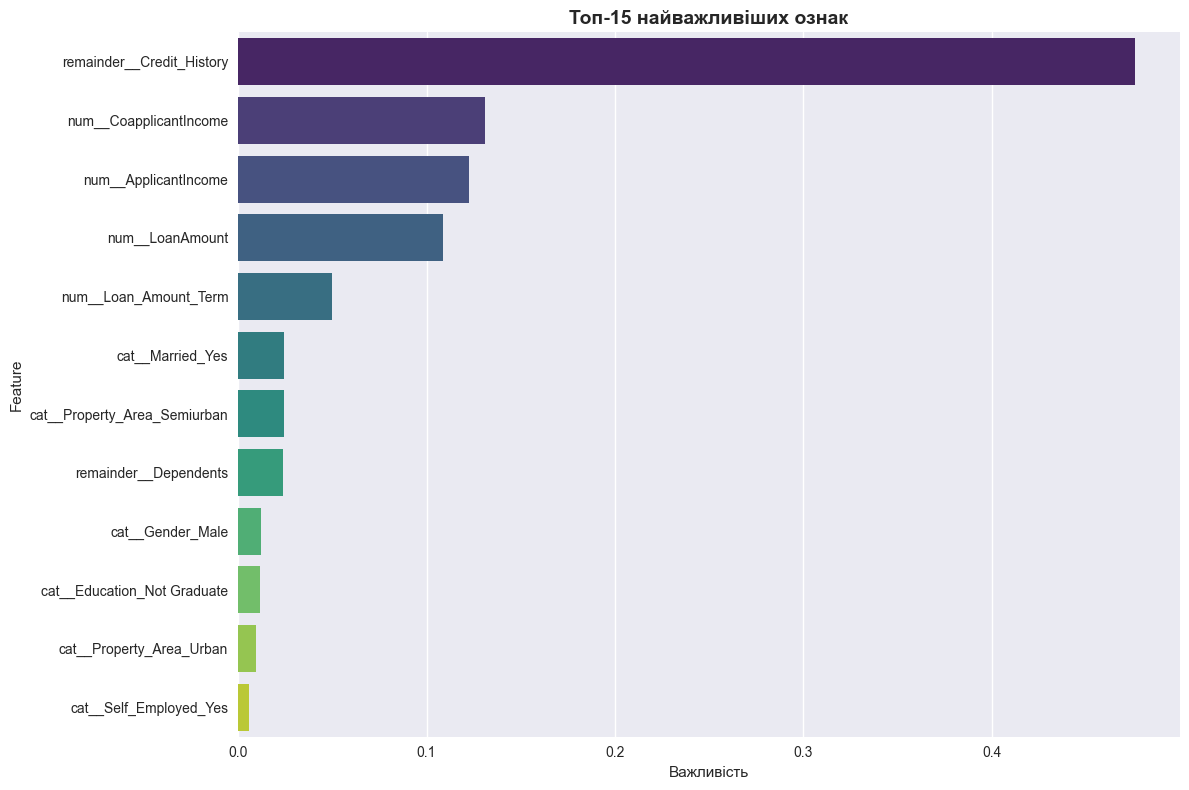

In [ ]:
# Візуалізація важливості ознак
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(15)
sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
plt.title('Топ-15 найважливіших ознак', fontsize=14, fontweight='bold')
plt.xlabel('Важливість')
plt.tight_layout()
plt.show()


## 8. Saving model - Збереження моделі


In [98]:
import pickle

# зберігаємо найкращу модель
with open("loan_model.pkl", "wb") as f:
    pickle.dump(grid.best_estimator_, f)

print("Модель збережено успішно як 'loan_model.pkl'")

# зберігаємо список стовпців для подальшого використання
with open("feature_columns.pkl", "wb") as f:
    pickle.dump(list(X.columns), f)

print("Список стовпців збережено як 'feature_columns.pkl'")


Модель збережено успішно як 'loan_model.pkl'
Список стовпців збережено як 'feature_columns.pkl'


## Висновки

1. Аналіз даних: Виявлено пропущені значення в кількох стовпцях, які були заповнені
2. Модель: RandomForestClassifier показав хороші результати
3. Важливі ознаки: Credit_History, LoanAmount, ApplicantIncome є найважливішими факторами
4. Точність: Модель досягла високої точності на тестовому наборі

Модель готова до використання в Django веб-застосунку!
